# Demo 2: Controlled Pendulum
## Demo 2.8: Update SysSimX

- **Connections**

- **System**

- **Resolving Computational Causality**

- **System Graph Creation**

In [48]:
import sys
import time
import numpy as np
from path import Path

repo_root = Path.getcwd().parent.parent
sys.path.insert(0, str(repo_root))

**Generate FMUComponents**

In [55]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.core.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path(demo_dir_path / 'ControlledPendulum')
fmu_output_dir = Path(demo_dir_path / 'FMUs')
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive2'], group='Actuator')
pendulum     = FMUComponent(name='pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorith

**Change unit of input ports for PID controller to match unit of input signals**

In [56]:
pid_input_unit1 = sensor_ref.outputs['U_q'].unit
pid_input_unit2 = sensor_state.outputs['U_q'].unit
pid_input_unit = None

if pid_input_unit1.is_compatible_with(pid_input_unit2):
    print(f"PID input units are compatible: {pid_input_unit1}, {pid_input_unit2}")
    pid_input_unit = pid_input_unit1
else:
    raise ValueError(f"PID input units are not compatible: {pid_input_unit1}, {pid_input_unit2}")

for input_port in pid.inputs.values():
    input_port.unit = pid_input_unit
    print(f"Set PID input port {input_port.name} unit to {input_port.unit}")

PID input units are compatible: V, V
Set PID input port ref unit to V
Set PID input port y unit to V


**Define Connections**

In [40]:
from SysSimX.system.connection import Connection

c1 = Connection(src_comp=ref, src_port=ref.outputs['q_ref'],
                dst_comp=sensor_ref, dst_port=sensor_ref.inputs['q'])

c2 = Connection(src_comp=pendulum, src_port=pendulum.outputs['q_state'],
                dst_comp=sensor_state, dst_port=sensor_state.inputs['q'],
                delay=1)

c3 = Connection(src_comp=sensor_ref, src_port=sensor_ref.outputs['U_q'],
                dst_comp=pid, dst_port=pid.inputs['ref'])

c4 = Connection(src_comp=sensor_state, src_port=sensor_state.outputs['U_q'],
                dst_comp=pid, dst_port=pid.inputs['y'])

c5 = Connection(src_comp=pid, src_port=pid.outputs['u'],
                dst_comp=drive, dst_port=drive.inputs['u_control'])

c6 = Connection(src_comp=drive, src_port=drive.outputs['torque'],
                dst_comp=pendulum, dst_port=pendulum.inputs['torque'])

c7 = Connection(src_comp=pendulum, src_port=pendulum.outputs['omega_state'],
                dst_comp=drive, dst_port=drive.inputs['omega'],
                delay=1)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [41]:
from SysSimX.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
system.add_connection(c1)
system.compute_execution_order()

Connection validation error:
Connection from ref.q_ref to sensor_ref.q already exists.


**Create System Graph**

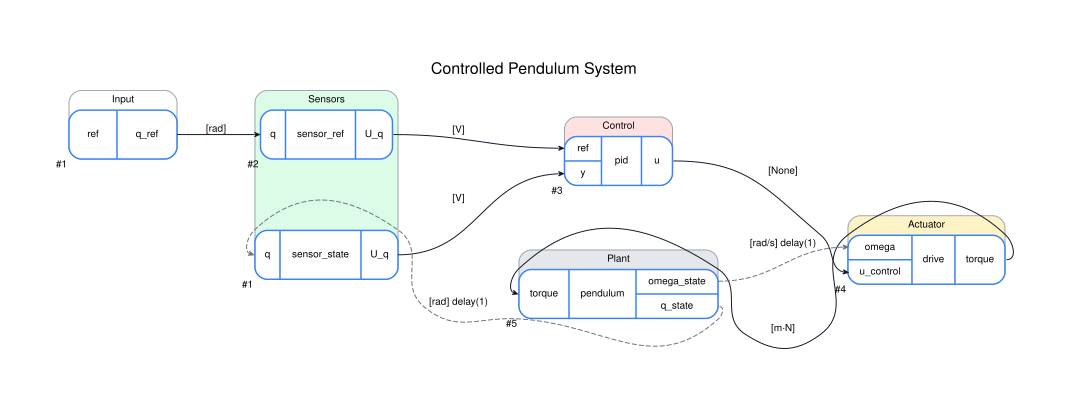

In [42]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

**Set Parameters and Initial Values**

In [57]:
# Parameters for reference signal
ref_freq = 1 # Hz
q_mean_deg = 0
q_ampl_deg = 20
ref.set_parameters(amplitude= np.deg2rad(q_ampl_deg),
                   frequency=ref_freq,
                   mean= np.deg2rad(q_mean_deg))

# Sensor configuartion
nbits = 12
sensor_ref.set_parameters(nBits=nbits,
                          q_max=np.deg2rad(q_mean_deg + q_ampl_deg),
                          q_min=np.deg2rad(q_mean_deg - q_ampl_deg))
sensor_state.set_parameters(nBits=nbits,
                            q_max=np.deg2rad(q_mean_deg + q_ampl_deg),
                            q_min=np.deg2rad(q_mean_deg - q_ampl_deg))

# PID controller configuration
pid.set_parameters(k=10, Ti=0.5, Td=0.25)

# Simulation parameters
t0, tf, h = 0, 1.5, 0.01


In [58]:
from SysSimX.components.opensim_pendulum import OpenSimPendulum
from SysSimX.fem.pendulum import FEMPendulum

# Initial Conditions
q0_deg  = 0
q0      = np.deg2rad(q0_deg)
omega0  = 0
q_wall_deg = 0

# Define FEM model
fem_pendulum  = FEMPendulum()

fem_pendulum.geom_params.use_wall = False
fem_pendulum.geom_params.q_wall_deg = q_wall_deg
fem_pendulum.sim_params.t_start = t0
fem_pendulum.sim_params.tau     = h
fem_pendulum.sim_params.t_end   = tf
fem_pendulum.init_params.angular_position_deg = q0_deg
fem_pendulum.init_params.angular_velocity     = omega0
fem_pendulum.init_params.angular_acceleration = 0
fem_pendulum._create_mesh()

# Get mass and inertia from FEM model
m_pendulum       = fem_pendulum.mass
inertia_pendulum = fem_pendulum.inertia
print(f"Pendulum mass: {m_pendulum:.3f} kg")
print(f"Pendulum inertia: {inertia_pendulum:.3f} kg m²")
L_computed = np.sqrt(inertia_pendulum / m_pendulum)

# Set parameters for FMU model
pendulum.parameters["m"].start = m_pendulum
pendulum.parameters["L"].start = L_computed
pendulum.parameters['q0'].start     = np.deg2rad(q0_deg)
pendulum.parameters['omega0'].start = omega0

# Wall contact angle
os_pendulum        = OpenSimPendulum()
os_pendulum.mass   = m_pendulum
os_pendulum.length = L_computed
os_pendulum.q0     = np.deg2rad(q0_deg)
os_pendulum.omega0 = omega0

Pendulum mass: 15.446 kg
Pendulum inertia: 7.000 kg m²
